# ITCS 6169/8169 — Computer Vision
## Assignment 1: The CNN Challenge
**Due: September 25, 2026 at 11:59 PM EDT**

---

In this assignment, you will build and train a convolutional neural network (CNN) for **16-class scene recognition** using a small dataset of **2,400 training images**.

This notebook is intentionally only a **starter baseline**. It provides a clean training pipeline and a deliberately simple CNN. Your task is to improve the system through informed decisions about architecture, optimization, augmentation, regularization, model selection, and training strategy.

### 2026 workflow: AI is your pair programmer
Use of an AI coding assistant (e.g., ChatGPT, Codex, GitHub Copilot, Claude Code, Gemini, Cursor) is **required**. You may use AI to help implement, debug, refactor, explain, or suggest experiments. However, **you are responsible for the scientific decisions and for verifying all generated code**.

Your final GitHub repository must include an `AI_USAGE.md` file describing representative AI-assisted tasks, at least one incorrect/ineffective AI suggestion, how you verified or corrected it, and one important decision that you made yourself.

### Important model restriction
The primary classifier for Assignment 1 must be a **CNN**. Do **not** use CLIP, DINO/DINOv2, VLM APIs, Vision Transformers as the primary model, or other foundation-model embeddings for your main submission. Pretrained CNNs are allowed if clearly documented.

### Google Colab
Google Colab is recommended, but not required. If using Colab, enable a GPU through **Runtime → Change runtime type → GPU**. You may also use the Educational Cluster or another resource for which you have authorized access.

In [ ]:
import sys
import torch
import torchvision

print("=== Environment Check ===")
print(f"Python version:     {sys.version}")
print(f"PyTorch version:    {torch.__version__}")
print(f"Torchvision version:{torchvision.__version__}")
print(f"CUDA available:     {torch.cuda.is_available()}")
print(f"PyTorch built with CUDA: {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"GPU device:         {torch.cuda.get_device_name(0)}")
    print(f"GPU count:          {torch.cuda.device_count()}")
    print(f"CUDA capability:    {torch.cuda.get_device_capability(0)}")
    print(f"Total GPU memory:   {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: CUDA not available — training will run on CPU (much slower).")
    print("Check: correct PyTorch build installed? NVIDIA driver installed? GPU recognized by OS?")

In [ ]:
import sys
import torch
import torchvision

print("=== Environment Check ===")
print(f"Python version:     {sys.version}")
print(f"PyTorch version:    {torch.__version__}")
print(f"Torchvision version:{torchvision.__version__}")
print(f"CUDA available:     {torch.cuda.is_available()}")
print(f"PyTorch built with CUDA: {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"GPU device:         {torch.cuda.get_device_name(0)}")
    print(f"GPU count:          {torch.cuda.device_count()}")
    print(f"CUDA capability:    {torch.cuda.get_device_capability(0)}")
    print(f"Total GPU memory:   {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: CUDA not available — training will run on CPU (much slower).")
    print("Check: correct PyTorch build installed? NVIDIA driver installed? GPU recognized by OS?")

In [ ]:
import os
for folder in ['train', 'test', 'test2']:
    path = DATA_ROOT / folder
    if path.exists():
        subdirs = [d for d in path.iterdir() if d.is_dir()]
        print(f"{folder}: {len(subdirs)} subfolders -> {[d.name for d in subdirs][:5]}")
    else:
        print(f"{folder}: NOT FOUND")

In [ ]:
import os
print(os.listdir(DATA_ROOT))

In [1]:
# Core imports
from pathlib import Path
import random
import time
import copy

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.12.0.dev20260408+cu128
CUDA available: True


In [2]:
# Optional: mount Google Drive when running in Colab.
# Skip this cell if you are running locally or on another server.
try:
    from google.colab import drive
    drive.mount('/content/gdrive')
except ImportError:
    print("Not running in Google Colab; Drive mount skipped.")

Not running in Google Colab; Drive mount skipped.


## 1. Set your working directory

Download the assignment dataset from the link provided in the assignment handout and organize it so that the notebook can find:

```text
data/
  train/
    class_1/
    ...
  test/
    class_1/
    ...
```

If you use Google Drive, change `PROJECT_ROOT` below to your assignment folder. **Do not hard-code a TA/instructor solution path.**

In [3]:
# CHANGE THIS PATH to your own assignment directory.
# Example for Colab + Google Drive:
# PROJECT_ROOT = Path('/content/gdrive/MyDrive/ITCS_6169_8169/assignment1')

PROJECT_ROOT = Path('.')
DATA_ROOT = PROJECT_ROOT / 'data'
TRAIN_ROOT = DATA_ROOT / 'train'
TEST_ROOT = DATA_ROOT / 'test'

print('Project root:', PROJECT_ROOT.resolve())
print('Training data:', TRAIN_ROOT)
print('Testing data:', TEST_ROOT)

Project root: C:\Users\omcka\Downloads\CV\assignment1\assignment1
Training data: data\train
Testing data: data\test


## 2. Reproducibility and device

A fixed seed makes the starter result easier to reproduce. Exact GPU reproducibility is not always guaranteed across hardware/software versions, so report your environment and seed in the final repository.

In [4]:
SEED = 0

def set_random_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_random_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 3. Loading and preprocessing the data

The starter baseline converts images to grayscale and resizes them to $64\times64$. This is **not necessarily a good final choice**. You should decide whether color, resolution, normalization, and augmentation should be changed.

We split the provided training data into **training and validation sets**. Use the validation set for architecture/hyperparameter decisions. **Do not repeatedly tune on the test set.** The test set should be used for the final evaluation of a selected model.

In [5]:
IMG_SIZE = 64
BATCH_SIZE = 64
VAL_FRACTION = 0.20

# Deliberately simple preprocessing for the starter baseline.
# TODO: improve this as part of your experiments.
baseline_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

full_train_dataset = datasets.ImageFolder(TRAIN_ROOT, transform=baseline_transform)
test_dataset = datasets.ImageFolder(TEST_ROOT, transform=baseline_transform)

class_names = full_train_dataset.classes
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')
print(f'Total training images: {len(full_train_dataset)}')
print(f'Test images: {len(test_dataset)}')

val_size = int(round(len(full_train_dataset) * VAL_FRACTION))
train_size = len(full_train_dataset) - val_size
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size], generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=torch.cuda.is_available())

print(f'Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}')

Classes (16): ['Bedroom', 'Coast', 'Flower', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']
Total training images: 2256
Test images: 400
Train: 1805 | Validation: 451 | Test: 400


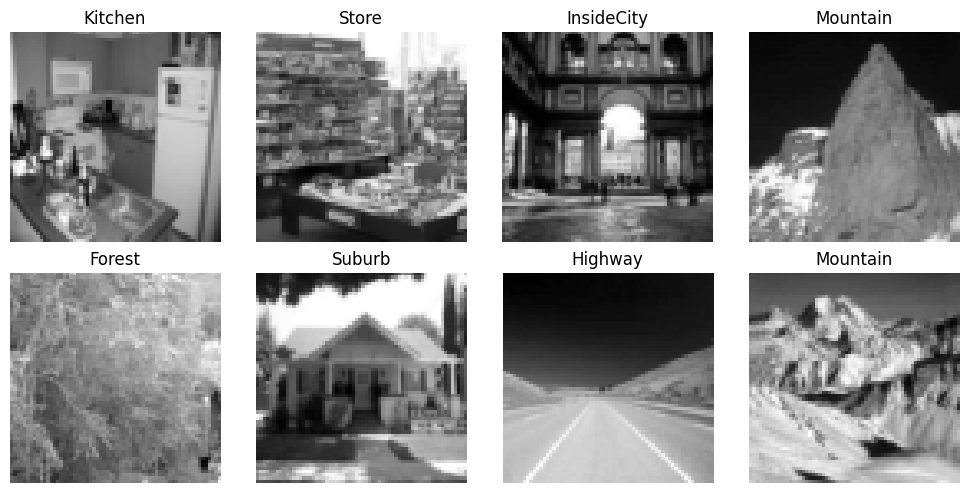

In [6]:
# Visualize a few training examples
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, image, label in zip(axes.flat, images[:8], labels[:8]):
    image = image * 0.5 + 0.5  # unnormalize
    ax.imshow(image.squeeze(0), cmap='gray')
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Training a CNN from scratch

Gone are the days when hand-designed features were the default solution. We will start with end-to-end learning and train a CNN directly for 16-way classification.

The architecture below is deliberately weak and simple. **Do not treat it as a recommended architecture.** It exists only to verify that the pipeline works and to give you a baseline to beat.

In [7]:
class TNet(nn.Module):
    """A deliberately small CNN starter baseline."""
    def __init__(self, num_classes=16):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=4, stride=4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 15 * 15, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = TNet(num_classes=num_classes)
print(model)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

TNet(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3600, out_features=16, bias=True)
  )
)
Trainable parameters: 57,776


## 5. Training and evaluation utilities

The training loop below selects the checkpoint with the **best validation accuracy**. This is a much better experimental practice than evaluating the test set after every epoch.

You are welcome to rewrite this code. For example, you may add a scheduler, mixed precision, early stopping, checkpointing, experiment tracking, or richer metrics. If AI helps you implement such changes, verify the implementation and document representative usage in `AI_USAGE.md`.

In [8]:
@torch.inference_mode()
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, optimizer, epochs=20, device=device):
    criterion = nn.CrossEntropyLoss()
    model = model.to(device)
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_seen = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            total_seen += labels.size(0)

        train_loss = total_loss / total_seen
        val_loss, val_acc = evaluate(model, val_loader, device)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
              f'val acc {val_acc:.4f} | {elapsed:.1f}s')

    model.load_state_dict(best_state)
    print(f'Best validation accuracy: {best_val_acc:.4f}')
    return model, history

In [9]:
# Train the deliberately simple baseline.
set_random_seed(SEED)
model = TNet(num_classes=num_classes)
optimizer = optim.Adam(model.parameters(), lr=0.002)

model, history = train_model(
    model, train_loader, val_loader, optimizer, epochs=20, device=device
)

Epoch 01/20 | train loss 2.4838 | val loss 2.1644 | val acc 0.3259 | 16.5s
Epoch 02/20 | train loss 1.9264 | val loss 1.8749 | val acc 0.4124 | 33.3s
Epoch 03/20 | train loss 1.5923 | val loss 1.8009 | val acc 0.4368 | 49.9s
Epoch 04/20 | train loss 1.3066 | val loss 1.6911 | val acc 0.4590 | 66.2s
Epoch 05/20 | train loss 1.0864 | val loss 1.6327 | val acc 0.5011 | 82.8s
Epoch 06/20 | train loss 0.9049 | val loss 1.6439 | val acc 0.4945 | 99.8s
Epoch 07/20 | train loss 0.8089 | val loss 1.6108 | val acc 0.5144 | 115.1s
Epoch 08/20 | train loss 0.6848 | val loss 1.6456 | val acc 0.5078 | 131.5s
Epoch 09/20 | train loss 0.5783 | val loss 1.6377 | val acc 0.5011 | 148.6s
Epoch 10/20 | train loss 0.4966 | val loss 1.6581 | val acc 0.5166 | 165.1s
Epoch 11/20 | train loss 0.4332 | val loss 1.6835 | val acc 0.4945 | 181.9s
Epoch 12/20 | train loss 0.3640 | val loss 1.6665 | val acc 0.5432 | 198.5s
Epoch 13/20 | train loss 0.3146 | val loss 1.8024 | val acc 0.5122 | 215.4s
Epoch 14/20 | trai

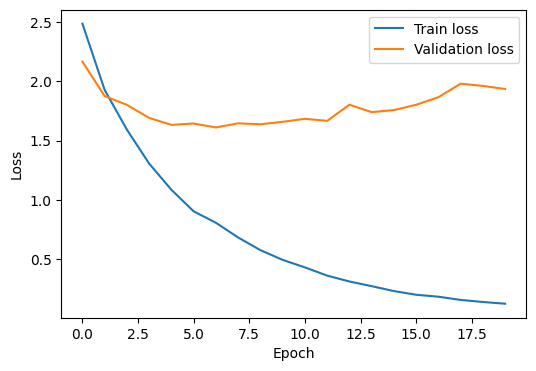

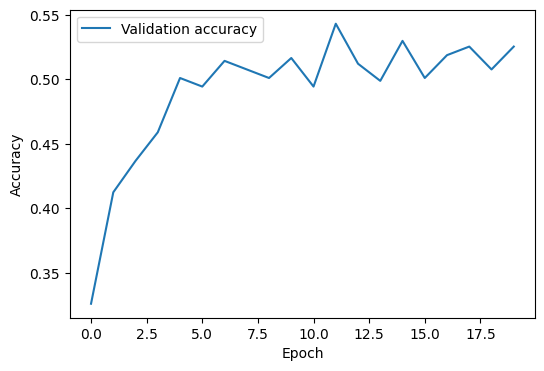

In [10]:
# Plot the starter training history.
plt.figure(figsize=(6, 4))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history['val_acc'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 6. Your turn: beat the baseline

This simple model should only be treated as a sanity check. Your objective is to substantially improve it.

Rather than asking an AI tool to ``make the accuracy higher,'' formulate hypotheses yourself. Examples of useful questions include whether the model is overfitting, whether color matters, whether stronger augmentation helps, whether a different CNN family is more appropriate, whether pretrained CNN features transfer well, or whether optimization/regularization is limiting performance.

For each important experiment, write down:

| Experiment | What changed? | Why did you try it? | Validation accuracy | What did you learn? |
|---|---|---|---:|---|
| Baseline | Starter TNet | Sanity check | 54.32% | network depth too low, agumentation selection is bad, very less optimization perfromed |
| Experiment 1 | ResNet18 | More established and accurate architecture | 94.90% | Pre-trained weights more reliable and useful to reduce computation if transfer learning is applied right |
| Experiment 2 | ResNet18 + cutmix + label smoothing + SGD | Tested pretrained weights with further optimizations, different optimizer, more mordern agumentation, more regularization | 94.90% | Didnt get any change in accuracy, maybe this is because of class imbalance as there is always one high 94.9 value compared to train average being around 92 and exp 2 average being around 93. In a previous but partially incorrect run (missing mountain class in training) Optimizations and changes did increase accuracy but the overall margin in change was low, since the picked changes should push accuracy higher as is pointed out in literature,  maybe its some other parameters that are affecting training |
| Final model | ResNet18 + cutmix + label smoothing + SGD + dropout + hyperparameter tuning | One more regularization and finiding the right hyperparameters to get the most out of the model in terms of accuracy | 95.79% | Didnt get much boost in accuracy as hyperparameters found to be best were already in use, dropout could've added a little bump in performance but that is not to be seen, having more epochs would've helped model learn more features but we had early stopping around epoch 49; preventing overfitting but my take is model is already overfitting because there is less data to learn from and high acuuracy suggests it has learnt the limited features well. |

**Do not use the test set to choose among these experiments.**

**Transfer Learning: ResNet18**

RGB 224x224 instead of grayscale
ImageNet mean/std normalization
Data augmentation (flip, crop, color jitter)
Pretrained ResNet18 backbone
Two-phase training: frozen backbone → fine-tune
Head is trained, backbone is frozen. All layers get unfrozen only for finetuning.

In [11]:
IMG_SIZE_RN18 = 224
BATCH_SIZE_RN18 = 32

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform_rn18 = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE_RN18, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform_rn18 = transforms.Compose([
    transforms.Resize((IMG_SIZE_RN18, IMG_SIZE_RN18)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

full_train_dataset_rn18 = datasets.ImageFolder(TRAIN_ROOT, transform=train_transform_rn18)
full_train_dataset_eval = datasets.ImageFolder(TRAIN_ROOT, transform=eval_transform_rn18)
test_dataset_rn18 = datasets.ImageFolder(TEST_ROOT, transform=eval_transform_rn18)

train_indices = train_dataset.indices
val_indices = val_dataset.indices

train_dataset_rn18 = torch.utils.data.Subset(full_train_dataset_rn18, train_indices)
val_dataset_rn18 = torch.utils.data.Subset(full_train_dataset_eval, val_indices)

train_loader_rn18 = DataLoader(train_dataset_rn18, batch_size=BATCH_SIZE_RN18, shuffle=True,
                                num_workers=4, pin_memory=torch.cuda.is_available())
val_loader_rn18 = DataLoader(val_dataset_rn18, batch_size=BATCH_SIZE_RN18, shuffle=False,
                              num_workers=4, pin_memory=torch.cuda.is_available())
test_loader_rn18 = DataLoader(test_dataset_rn18, batch_size=BATCH_SIZE_RN18, shuffle=False,
                               num_workers=4, pin_memory=torch.cuda.is_available())

print(f'Train: {len(train_dataset_rn18)} | Val: {len(val_dataset_rn18)} | Test: {len(test_dataset_rn18)}')

Train: 1805 | Val: 451 | Test: 400


In [12]:
from torchvision import models
from torchvision.models import ResNet18_Weights

def build_resnet18(num_classes=16, freeze_backbone=True):
    model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model

model_rn18 = build_resnet18(num_classes=num_classes, freeze_backbone=True)
trainable = sum(p.numel() for p in model_rn18.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_rn18.parameters())
print(f'Trainable parameters: {trainable:,} / {total:,} total')

Trainable parameters: 8,208 / 11,184,720 total


In [13]:
set_random_seed(SEED)
optimizer_rn18_phase1 = optim.Adam(model_rn18.fc.parameters(), lr=1e-3)

model_rn18, history_rn18_phase1 = train_model(
    model_rn18, train_loader_rn18, val_loader_rn18, optimizer_rn18_phase1,
    epochs=10, device=device
)

Epoch 01/10 | train loss 1.7813 | val loss 1.0183 | val acc 0.7716 | 30.6s
Epoch 02/10 | train loss 0.8522 | val loss 0.6249 | val acc 0.8470 | 61.8s
Epoch 03/10 | train loss 0.6202 | val loss 0.4955 | val acc 0.8736 | 92.1s
Epoch 04/10 | train loss 0.4885 | val loss 0.4175 | val acc 0.8869 | 124.9s
Epoch 05/10 | train loss 0.4295 | val loss 0.3666 | val acc 0.9024 | 155.6s
Epoch 06/10 | train loss 0.3845 | val loss 0.3412 | val acc 0.9047 | 186.1s
Epoch 07/10 | train loss 0.3426 | val loss 0.3663 | val acc 0.8825 | 216.9s
Epoch 08/10 | train loss 0.3187 | val loss 0.3303 | val acc 0.8936 | 246.7s
Epoch 09/10 | train loss 0.3046 | val loss 0.2983 | val acc 0.9135 | 276.6s
Epoch 10/10 | train loss 0.2958 | val loss 0.2924 | val acc 0.9002 | 305.8s
Best validation accuracy: 0.9135


In [14]:
for param in model_rn18.parameters():
    param.requires_grad = True

optimizer_rn18_phase2 = optim.Adam(model_rn18.parameters(), lr=1e-5)

model_rn18, history_rn18_phase2 = train_model(
    model_rn18, train_loader_rn18, val_loader_rn18, optimizer_rn18_phase2,
    epochs=15, device=device
)

Epoch 01/15 | train loss 0.2623 | val loss 0.2458 | val acc 0.9224 | 29.8s
Epoch 02/15 | train loss 0.2069 | val loss 0.2173 | val acc 0.9202 | 60.0s
Epoch 03/15 | train loss 0.1575 | val loss 0.1913 | val acc 0.9335 | 91.0s
Epoch 04/15 | train loss 0.1401 | val loss 0.1792 | val acc 0.9335 | 121.5s
Epoch 05/15 | train loss 0.1201 | val loss 0.1754 | val acc 0.9357 | 154.0s
Epoch 06/15 | train loss 0.1060 | val loss 0.1644 | val acc 0.9379 | 186.2s
Epoch 07/15 | train loss 0.0849 | val loss 0.1606 | val acc 0.9379 | 218.2s
Epoch 08/15 | train loss 0.0755 | val loss 0.1670 | val acc 0.9401 | 248.6s
Epoch 09/15 | train loss 0.0671 | val loss 0.1610 | val acc 0.9424 | 278.9s
Epoch 10/15 | train loss 0.0573 | val loss 0.1472 | val acc 0.9446 | 309.1s
Epoch 11/15 | train loss 0.0534 | val loss 0.1475 | val acc 0.9490 | 340.3s
Epoch 12/15 | train loss 0.0476 | val loss 0.1463 | val acc 0.9424 | 370.6s
Epoch 13/15 | train loss 0.0433 | val loss 0.1521 | val acc 0.9379 | 400.9s
Epoch 14/15 | t

In [15]:
val_loss_rn18, val_acc_rn18 = evaluate(model_rn18, val_loader_rn18, device)
print(f'ResNet18 final validation accuracy: {val_acc_rn18:.4f}')

ResNet18 final validation accuracy: 0.9490


**Further ooptimizations:** 
- Mixup / CutMix augmentation
- Label smoothing
- Early stopping (patience-based)
- Switch optimizer: SGD + momentum + cosine LR schedule

In [16]:
from torchvision.transforms import v2

cutmix = v2.CutMix(num_classes=num_classes)
mixup = v2.MixUp(num_classes=num_classes)
cutmix_or_mixup = v2.RandomChoice([cutmix, mixup])

In [17]:
def train_model_v2(model, train_loader, val_loader, optimizer, scheduler=None,
                    epochs=30, patience=7, label_smoothing=0.1,
                    use_mixup_cutmix=True, device=device):
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    model = model.to(device)
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_seen = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if use_mixup_cutmix:
                images, labels = cutmix_or_mixup(images, labels)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            total_seen += images.size(0)

        if scheduler is not None:
            scheduler.step()

        train_loss = total_loss / total_seen
        val_loss, val_acc = evaluate(model, val_loader, device)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        elapsed = time.time() - start
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
              f'val acc {val_acc:.4f} | lr {current_lr:.6f} | {elapsed:.1f}s')

        if epochs_no_improve >= patience:
            print(f'Early stopping triggered after {epoch} epochs (no improvement for {patience} epochs).')
            break

    model.load_state_dict(best_state)
    print(f'Best validation accuracy: {best_val_acc:.4f}')
    return model, history

In [18]:
set_random_seed(SEED)
model_v2 = build_resnet18(num_classes=num_classes, freeze_backbone=False)  # start unfrozen this run
model_v2.load_state_dict(model_rn18.state_dict())  # warm-start from previous best checkpoint

optimizer_v2 = optim.SGD(model_v2.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler_v2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_v2, T_max=30)

model_v2, history_v2 = train_model_v2(
    model_v2, train_loader_rn18, val_loader_rn18, optimizer_v2, scheduler_v2,
    epochs=30, patience=7, label_smoothing=0.1, use_mixup_cutmix=True, device=device
)

Epoch 01/30 | train loss 1.9194 | val loss 1.0412 | val acc 0.7162 | lr 0.009973 | 30.9s
Epoch 02/30 | train loss 1.9208 | val loss 0.7124 | val acc 0.8071 | lr 0.009891 | 63.0s
Epoch 03/30 | train loss 1.8504 | val loss 0.6792 | val acc 0.8027 | lr 0.009755 | 94.2s
Epoch 04/30 | train loss 1.6489 | val loss 0.5171 | val acc 0.8869 | lr 0.009568 | 125.1s
Epoch 05/30 | train loss 1.7000 | val loss 0.6716 | val acc 0.8137 | lr 0.009330 | 157.4s
Epoch 06/30 | train loss 1.6575 | val loss 0.5100 | val acc 0.8758 | lr 0.009045 | 187.2s
Epoch 07/30 | train loss 1.6162 | val loss 0.5035 | val acc 0.8625 | lr 0.008716 | 217.6s
Epoch 08/30 | train loss 1.4890 | val loss 0.4347 | val acc 0.9135 | lr 0.008346 | 248.0s
Epoch 09/30 | train loss 1.5005 | val loss 0.4374 | val acc 0.9091 | lr 0.007939 | 279.1s
Epoch 10/30 | train loss 1.4709 | val loss 0.4326 | val acc 0.9157 | lr 0.007500 | 310.4s
Epoch 11/30 | train loss 1.4093 | val loss 0.4620 | val acc 0.9268 | lr 0.007034 | 341.0s
Epoch 12/30 |

**HyperParameter Finetuning:**

Targeted params: epochs, LR, cutmix strength
added dropout

In [19]:
def set_head_dropout(model, num_classes, dropout_rate):
    in_features = model.fc.in_features
    if dropout_rate > 0:
        model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes)
        )
    else:
        model.fc = nn.Linear(in_features, num_classes)
    return model

In [20]:
def probe_run(lr, alpha, dropout_rate, probe_epochs=5, label_smoothing=0.1, device=device):
    set_random_seed(SEED)

    #warm-started from 93.11% checkpoint
    model_probe = build_resnet18(num_classes=num_classes, freeze_backbone=False)
    model_probe.load_state_dict(model_rn18.state_dict())
    model_probe = set_head_dropout(model_probe, num_classes, dropout_rate)
    model_probe = model_probe.to(device)

    # Mixup/CutMix with specified alpha
    cutmix_p = v2.CutMix(num_classes=num_classes, alpha=alpha)
    mixup_p = v2.MixUp(num_classes=num_classes, alpha=alpha)
    cutmix_or_mixup_p = v2.RandomChoice([cutmix_p, mixup_p])

    optimizer_probe = optim.SGD(model_probe.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    scheduler_probe = optim.lr_scheduler.CosineAnnealingLR(optimizer_probe, T_max=probe_epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    for epoch in range(probe_epochs):
        model_probe.train()
        for images, labels in train_loader_rn18:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            images, labels = cutmix_or_mixup_p(images, labels)

            optimizer_probe.zero_grad(set_to_none=True)
            logits = model_probe(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer_probe.step()
        scheduler_probe.step()

    _, val_acc = evaluate(model_probe, val_loader_rn18, device)
    return val_acc

In [ ]:
#testing for different values of these hyperparameters to find the best possible value (probe runs are 5 epochs each)
DEFAULT_LR = 0.01
DEFAULT_ALPHA = 1.0
DEFAULT_DROPOUT = 0.0

results = {}

print("=== Probing Learning Rate ===")
for lr in [0.1, 0.03, 0.01, 0.003]:
    acc = probe_run(lr=lr, alpha=DEFAULT_ALPHA, dropout_rate=DEFAULT_DROPOUT)
    results[f'lr={lr}'] = acc
    print(f'lr={lr}: val_acc={acc:.4f}')

print("\n=== Probing Mixup/CutMix Alpha ===")
for alpha in [0.2, 0.4, 1.0]:
    acc = probe_run(lr=DEFAULT_LR, alpha=alpha, dropout_rate=DEFAULT_DROPOUT)
    results[f'alpha={alpha}'] = acc
    print(f'alpha={alpha}: val_acc={acc:.4f}')

print("\n=== Probing Dropout ===")
for dropout_rate in [0.0, 0.3, 0.5]:
    acc = probe_run(lr=DEFAULT_LR, alpha=DEFAULT_ALPHA, dropout_rate=dropout_rate)
    results[f'dropout={dropout_rate}'] = acc
    print(f'dropout={dropout_rate}: val_acc={acc:.4f}')

print("\n=== All Results ===")
for k, v in sorted(results.items(), key=lambda x: -x[1]):
    print(f'{k}: {v:.4f}')

In [22]:
FINAL_EPOCHS = 70
FINAL_PATIENCE = 10
FINAL_LR = 0.01
FINAL_ALPHA = 1.0
FINAL_DROPOUT = 0.3

# best probes from previous run:
# alpha=1.0: 0.9264
# dropout=0.3: 0.9216
# lr=0.01: 0.9192

set_random_seed(SEED)

model_final = build_resnet18(num_classes=num_classes, freeze_backbone=False)
model_final.load_state_dict(model_rn18.state_dict())  # warm-start from 93.11% checkpoint
model_final = set_head_dropout(model_final, num_classes, FINAL_DROPOUT)
model_final = model_final.to(device)

cutmix_final = v2.CutMix(num_classes=num_classes, alpha=FINAL_ALPHA)
mixup_final = v2.MixUp(num_classes=num_classes, alpha=FINAL_ALPHA)
cutmix_or_mixup_final = v2.RandomChoice([cutmix_final, mixup_final])

optimizer_final = optim.SGD(model_final.parameters(), lr=FINAL_LR, momentum=0.9, weight_decay=1e-4)
scheduler_final = optim.lr_scheduler.CosineAnnealingLR(optimizer_final, T_max=FINAL_EPOCHS)

In [23]:
model_final, history_final = train_model_v2(
    model_final, train_loader_rn18, val_loader_rn18, optimizer_final, scheduler_final,
    epochs=FINAL_EPOCHS, patience=FINAL_PATIENCE, label_smoothing=0.1,
    use_mixup_cutmix=True, device=device
)

Epoch 01/70 | train loss 2.0433 | val loss 0.7332 | val acc 0.7871 | lr 0.009995 | 32.6s
Epoch 02/70 | train loss 1.9492 | val loss 0.9334 | val acc 0.7517 | lr 0.009980 | 64.6s
Epoch 03/70 | train loss 1.7922 | val loss 0.8096 | val acc 0.7295 | lr 0.009955 | 98.4s
Epoch 04/70 | train loss 1.7865 | val loss 0.4873 | val acc 0.8936 | lr 0.009920 | 130.9s
Epoch 05/70 | train loss 1.7890 | val loss 0.5673 | val acc 0.8492 | lr 0.009875 | 162.8s
Epoch 06/70 | train loss 1.6539 | val loss 0.4369 | val acc 0.9135 | lr 0.009820 | 195.3s
Epoch 07/70 | train loss 1.5625 | val loss 0.3950 | val acc 0.9157 | lr 0.009755 | 227.3s
Epoch 08/70 | train loss 1.6911 | val loss 0.5545 | val acc 0.8825 | lr 0.009681 | 259.4s
Epoch 09/70 | train loss 1.6331 | val loss 0.5226 | val acc 0.8958 | lr 0.009598 | 291.4s
Epoch 10/70 | train loss 1.6317 | val loss 0.4634 | val acc 0.9157 | lr 0.009505 | 324.2s
Epoch 11/70 | train loss 1.5483 | val loss 0.4762 | val acc 0.9180 | lr 0.009403 | 356.4s
Epoch 12/70 |

In [24]:
# FINAL TEST EVALUATION
# Run this only after you have selected your final model using validation results.

test_loss, test_acc = evaluate(model_final, test_loader_rn18, device)
print(f'Final test loss: {test_loss:.4f}')
print(f'Final test accuracy: {test_acc:.4f}')

Final test loss: 0.5999
Final test accuracy: 0.8825


In [25]:
import torch
from pathlib import Path

Path("checkpoints").mkdir(exist_ok=True)

torch.save({
    "model_state_dict": model_final.state_dict(),
    "class_names": class_names,
    "num_classes": num_classes,
    "config": {
        "model": {"backbone": "resnet18", "pretrained": True, "dropout": FINAL_DROPOUT},
        "data": {
            "train_root": "dataset/train",
            "test_root": "dataset/test",
            "img_size": IMG_SIZE_RN18,
            "batch_size": BATCH_SIZE_RN18,
            "num_workers": 4,
        },
    },
    "best_val_acc": max(history_final["val_acc"]),
    "seed": SEED,
}, "checkpoints/resnet18_final.pth")

print("Checkpoint saved to checkpoints/resnet18_final.pth")

Checkpoint saved to checkpoints/resnet18_final.pth


## 7. AI-assisted development checkpoint

Before submission, create `AI_USAGE.md` in your GitHub repository. You do **not** need to provide every prompt. Include:

1. the AI coding tool(s) you used;
2. 3--5 representative ways AI assisted you;
3. at least one AI suggestion that was incorrect, ineffective, or questionable;
4. how you tested, verified, corrected, or rejected that suggestion; and
5. one important architecture/experimental decision that **you** made.

A good entry describes the engineering/research interaction rather than saying only, ``I used ChatGPT to write code.''

### A useful habit
When AI generates code, ask yourself before running it:
- What do I expect this code to do?
- What assumption is it making about tensor shape/data/model behavior?
- How will I know if it is wrong?
- What experiment would distinguish a real improvement from noise?

## 8. GitHub and submission requirements

All assignment code must be maintained in **GitHub** (not GitLab). Your repository should contain a meaningful commit history and, at minimum:

```text
README.md
AI_USAGE.md
training / model code
inference or evaluation code
requirements.txt or environment information
final checkpoint or a link to it
reproduction instructions
```

Do not create the entire repository as a single commit immediately before the deadline. Use Git throughout development as you would in a real research or engineering project.

Your final submission is a **maximum two-page PDF report** containing the working GitHub link. The report should clearly state your best result, validation/model-selection strategy, final recipe, important experiments, at least one failure analysis, and a brief AI+human reflection.

Friendly discussion and brainstorming are encouraged, but your implementation, experiments, report, and repository must be your own. Do not share code, checkpoints, detailed hyperparameters, or test predictions before the deadline.

The instructor may ask you to explain any important component of your submitted system. You are responsible for understanding all code in your final repository, including AI-generated code.

**Deadline: September 25, 2026 at 11:59 PM EDT.**

Good luck — and treat this as your first small computer vision research project of the semester.